In [1]:
#Restricted Area --------------------------------------------

In [2]:
#Linear

<Figure size 1200x800 with 0 Axes>

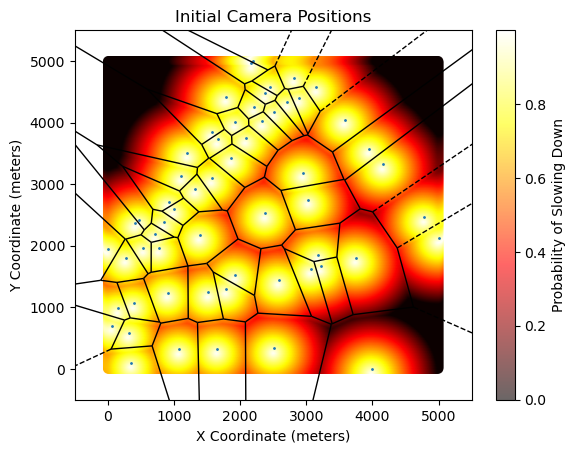

Initial Average Coverage Probability: 0.6267869728205457
No eligible cameras left to move or all remaining cameras exceed the accident threshold.


<Figure size 1200x800 with 0 Axes>

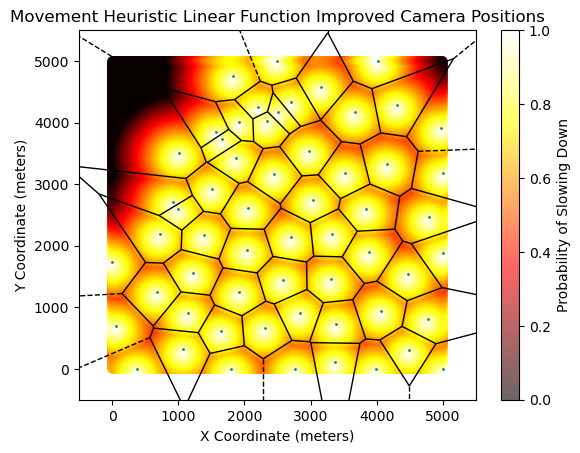

Optimized Average Coverage Probability: 0.6334424575001281
Total number of cameras required: 58
Original number of cameras: 58
Camera positions (X, Y):
Camera 1: (X: 4769.54, Y: 811.62)
Camera 2: (X: 61.02, Y: 698.69)
Camera 3: (X: 3527.05, Y: 3176.35)
Camera 4: (X: 0.00, Y: 1733.47)
Camera 5: (X: 3877.76, Y: 1893.79)
Camera 6: (X: 380.76, Y: 0.00)
Camera 7: (X: 4969.94, Y: 3917.84)
Camera 8: (X: 2034.07, Y: 1933.87)
Camera 9: (X: 4028.06, Y: 5000.00)
Camera 10: (X: 3386.77, Y: 731.46)
Camera 11: (X: 717.37, Y: 2188.10)
Camera 12: (X: 5000.00, Y: 0.00)
Camera 13: (X: 3326.65, Y: 2194.39)
Camera 14: (X: 681.36, Y: 1252.51)
Camera 15: (X: 917.99, Y: 2710.98)
Camera 16: (X: 996.36, Y: 2590.32)
Camera 17: (X: 1078.02, Y: 316.93)
Camera 18: (X: 3837.68, Y: 2595.19)
Camera 19: (X: 1012.02, Y: 3507.01)
Camera 20: (X: 3376.75, Y: 110.22)
Camera 21: (X: 1386.97, Y: 2169.47)
Camera 22: (X: 1222.44, Y: 1563.13)
Camera 23: (X: 1513.03, Y: 2925.85)
Camera 24: (X: 1574.36, Y: 3845.80)
Camera 25: (X:

NameError: name 'final_probabilities' is not defined

In [8]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.6  # Probability threshold for coverage

# Function to check if a point is inside the exclusion triangle
def is_inside_triangle(pt, v1, v2, v3):
    def sign(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    b1 = sign(pt, v1, v2) <= 0.0
    b2 = sign(pt, v2, v3) <= 0.0
    b3 = sign(pt, v3, v1) <= 0.0

    return ((b1 == b2) and (b2 == b3))

# Triangle vertices
v1 = (0, 2000)
v2 = (0, 5000)
v3 = (2000, 5000)


def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability


# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)





def optimize_camera_placements_with_weights(grid_points, camera_positions, siniestros, calculate_voronoi_coverage, coverage_threshold=0.5, accident_threshold=8, num_iterations=200, movement_limit=3, min_distance=250):
    camera_movement_count = [0] * len(camera_positions)
    no_improvement_count = 0
    
    for iteration in range(num_iterations):
        coverage = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
        if all(c <= coverage_threshold for c in coverage):
            print(f"All cameras below coverage threshold at iteration {iteration + 1}.")
            break
        
        eligible_cameras = [i for i in range(len(camera_positions)) if siniestros[i] < accident_threshold and camera_movement_count[i] < movement_limit]
        if not eligible_cameras:
            print("No eligible cameras left to move or all remaining cameras exceed the accident threshold.")
            break

        camera_to_move = min(eligible_cameras, key=lambda x: siniestros[x])
        camera_movement_count[camera_to_move] += 1

        # Find a new position outside the exclusion zone and respecting the minimum distance
        for idx in np.argsort(probability_of_slowing(np.min(pairwise_distances(grid_points, camera_positions), axis=1))):
            potential_new_position = grid_points[idx]
            if is_inside_triangle(potential_new_position, v1, v2, v3):
                continue  # Skip positions inside the exclusion zone
            
            # Check distance from all other cameras
            if all(np.linalg.norm(potential_new_position - other_pos) >= min_distance for other_pos in camera_positions if not np.array_equal(other_pos, camera_positions[camera_to_move])):
                camera_positions[camera_to_move] = potential_new_position
                break
        else:
            print("No valid camera positions found that meet all criteria.")
            break

        new_coverage = calculate_voronoi_coverage(grid_points, camera_positions)
        if new_coverage <= coverage_threshold:
            no_improvement_count += 1
            if no_improvement_count > movement_limit:
                print("No significant improvement, stopping optimization.")
                break

    return camera_positions


# Correctly pass 'provi_df' to the function call
optimized_camera_positions = optimize_camera_placements_with_weights(
    grid_points=grid_points,
    camera_positions=camera_positions.copy(),
    siniestros=siniestros,
    calculate_voronoi_coverage=calculate_voronoi_coverage,
    coverage_threshold=0.09,  # Optional: Adjust as needed
    accident_threshold=8,    # Optional: Adjust as needed
    num_iterations=200,      # Optional: Adjust as needed
    movement_limit=2         # Optional: Adjust as needed
)



# Calculate probabilities for the optimized positions
distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)

# Plot the optimized camera positions
plot_voronoi(optimized_camera_positions, probabilities, 'Movement Heuristic Linear Function Improved Camera Positions')
initial_optimized_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {initial_optimized_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)



camera_positions = optimized_camera_positions
# Final number of cameras and their coordinates
print(f"Total number of cameras required: {len(camera_positions)}")
print(f"Original number of cameras: {len(scaled_crash_points)}")
print("Camera positions (X, Y):")
for i, pos in enumerate(camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
#print(f"Total iterations: {total_iterations}")
print(" ")

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Heuristic/Heuristic_Linear.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)



# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")


In [4]:
#Logarithmic

<Figure size 1200x800 with 0 Axes>

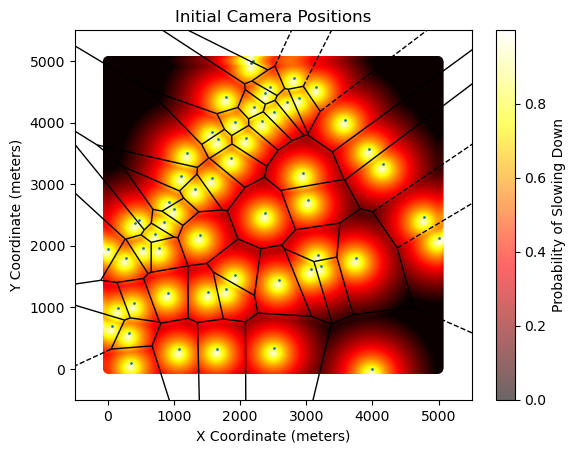

Initial Average Coverage Probability: 0.4558055255549537
No eligible cameras left to move or all remaining cameras exceed the accident threshold.


<Figure size 1200x800 with 0 Axes>

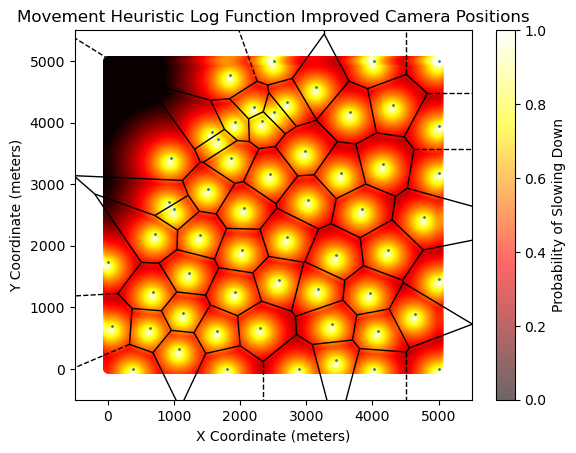

Optimized Average Coverage Probability: 0.3761607601655162
Total number of cameras required: 58
Original number of cameras: 58
Camera positions (X, Y):
Camera 1: (X: 5000.00, Y: 5000.00)
Camera 2: (X: 61.02, Y: 698.69)
Camera 3: (X: 4028.06, Y: 0.00)
Camera 4: (X: 3957.92, Y: 1232.46)
Camera 5: (X: 0.00, Y: 1733.47)
Camera 6: (X: 1653.31, Y: 621.24)
Camera 7: (X: 4639.28, Y: 891.78)
Camera 8: (X: 2034.07, Y: 1933.87)
Camera 9: (X: 5000.00, Y: 3947.90)
Camera 10: (X: 4028.06, Y: 5000.00)
Camera 11: (X: 717.37, Y: 2188.10)
Camera 12: (X: 5000.00, Y: 0.00)
Camera 13: (X: 380.76, Y: 0.00)
Camera 14: (X: 4078.16, Y: 621.24)
Camera 15: (X: 917.99, Y: 2710.98)
Camera 16: (X: 996.36, Y: 2590.32)
Camera 17: (X: 1078.02, Y: 316.93)
Camera 18: (X: 3386.77, Y: 731.46)
Camera 19: (X: 681.36, Y: 1252.51)
Camera 20: (X: 951.90, Y: 3426.85)
Camera 21: (X: 1386.97, Y: 2169.47)
Camera 22: (X: 3176.35, Y: 1302.61)
Camera 23: (X: 1222.44, Y: 1563.13)
Camera 24: (X: 1574.36, Y: 3845.80)
Camera 25: (X: 3837

In [9]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.6  # Probability threshold for coverage

# Function to check if a point is inside the exclusion triangle
def is_inside_triangle(pt, v1, v2, v3):
    def sign(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    b1 = sign(pt, v1, v2) <= 0.0
    b2 = sign(pt, v2, v3) <= 0.0
    b3 = sign(pt, v3, v1) <= 0.0

    return ((b1 == b2) and (b2 == b3))

# Triangle vertices
v1 = (0, 2000)
v2 = (0, 5000)
v3 = (2000, 5000)


def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability


# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)

def optimize_camera_placements_with_weights(grid_points, camera_positions, siniestros, calculate_voronoi_coverage, coverage_threshold=0.5, accident_threshold=8, num_iterations=200, movement_limit=3, min_distance=250):
    camera_movement_count = [0] * len(camera_positions)
    no_improvement_count = 0
    
    for iteration in range(num_iterations):
        coverage = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
        if all(c <= coverage_threshold for c in coverage):
            print(f"All cameras below coverage threshold at iteration {iteration + 1}.")
            break
        
        eligible_cameras = [i for i in range(len(camera_positions)) if siniestros[i] < accident_threshold and camera_movement_count[i] < movement_limit]
        if not eligible_cameras:
            print("No eligible cameras left to move or all remaining cameras exceed the accident threshold.")
            break

        camera_to_move = min(eligible_cameras, key=lambda x: siniestros[x])
        camera_movement_count[camera_to_move] += 1

        # Find a new position outside the exclusion zone and respecting the minimum distance
        for idx in np.argsort(probability_of_slowing(np.min(pairwise_distances(grid_points, camera_positions), axis=1))):
            potential_new_position = grid_points[idx]
            if is_inside_triangle(potential_new_position, v1, v2, v3):
                continue  # Skip positions inside the exclusion zone
            
            # Check distance from all other cameras
            if all(np.linalg.norm(potential_new_position - other_pos) >= min_distance for other_pos in camera_positions if not np.array_equal(other_pos, camera_positions[camera_to_move])):
                camera_positions[camera_to_move] = potential_new_position
                break
        else:
            print("No valid camera positions found that meet all criteria.")
            break

        new_coverage = calculate_voronoi_coverage(grid_points, camera_positions)
        if new_coverage <= coverage_threshold:
            no_improvement_count += 1
            if no_improvement_count > movement_limit:
                print("No significant improvement, stopping optimization.")
                break

    return camera_positions

# Correctly pass 'provi_df' to the function call
optimized_camera_positions = optimize_camera_placements_with_weights(
    grid_points=grid_points,
    camera_positions=camera_positions.copy(),
    siniestros=siniestros,
    calculate_voronoi_coverage=calculate_voronoi_coverage,
    coverage_threshold=0.09,  # Optional: Adjust as needed
    accident_threshold=8,    # Optional: Adjust as needed
    num_iterations=300,      # Optional: Adjust as needed
    movement_limit=3         # Optional: Adjust as needed
)



# Calculate probabilities for the optimized positions
distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)

# Plot the optimized camera positions
plot_voronoi(optimized_camera_positions, probabilities, 'Movement Heuristic Log Function Improved Camera Positions')
initial_optimized_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {initial_optimized_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)



camera_positions = optimized_camera_positions
# Final number of cameras and their coordinates
print(f"Total number of cameras required: {len(camera_positions)}")
print(f"Original number of cameras: {len(scaled_crash_points)}")
print("Camera positions (X, Y):")
for i, pos in enumerate(camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
#print(f"Total iterations: {total_iterations}")
print(" ")
# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Heuristic/Heuristic_Logarithmic.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")


In [6]:
#Quadratic

<Figure size 1200x800 with 0 Axes>

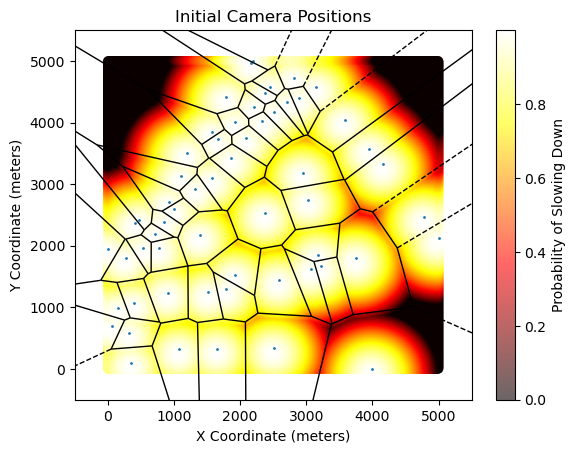

Initial Average Coverage Probability: 0.8054848220384362
No eligible cameras left to move or all remaining cameras exceed the accident threshold.


<Figure size 1200x800 with 0 Axes>

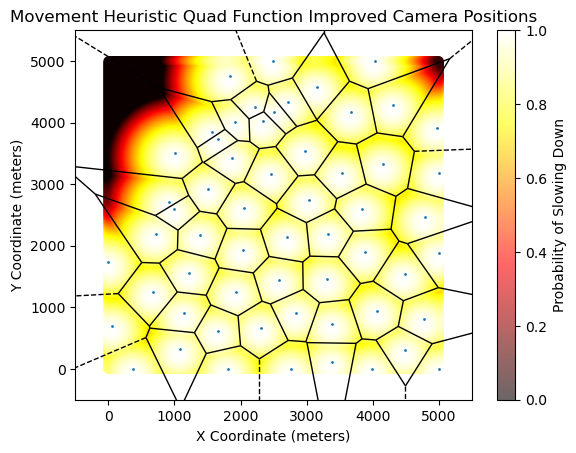

Optimized Average Coverage Probability: 0.8304307683429173
Total number of cameras required: 58
Original number of cameras: 58
Camera positions (X, Y):
Camera 1: (X: 4769.54, Y: 811.62)
Camera 2: (X: 61.02, Y: 698.69)
Camera 3: (X: 3527.05, Y: 3176.35)
Camera 4: (X: 0.00, Y: 1733.47)
Camera 5: (X: 3877.76, Y: 1893.79)
Camera 6: (X: 380.76, Y: 0.00)
Camera 7: (X: 4969.94, Y: 3917.84)
Camera 8: (X: 2034.07, Y: 1933.87)
Camera 9: (X: 4028.06, Y: 5000.00)
Camera 10: (X: 3386.77, Y: 731.46)
Camera 11: (X: 717.37, Y: 2188.10)
Camera 12: (X: 5000.00, Y: 0.00)
Camera 13: (X: 3326.65, Y: 2194.39)
Camera 14: (X: 681.36, Y: 1252.51)
Camera 15: (X: 917.99, Y: 2710.98)
Camera 16: (X: 996.36, Y: 2590.32)
Camera 17: (X: 1078.02, Y: 316.93)
Camera 18: (X: 3837.68, Y: 2595.19)
Camera 19: (X: 1012.02, Y: 3507.01)
Camera 20: (X: 3376.75, Y: 110.22)
Camera 21: (X: 1386.97, Y: 2169.47)
Camera 22: (X: 1222.44, Y: 1563.13)
Camera 23: (X: 1513.03, Y: 2925.85)
Camera 24: (X: 1574.36, Y: 3845.80)
Camera 25: (X:

In [10]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.6  # Probability threshold for coverage

# Function to check if a point is inside the exclusion triangle
def is_inside_triangle(pt, v1, v2, v3):
    def sign(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    b1 = sign(pt, v1, v2) <= 0.0
    b2 = sign(pt, v2, v3) <= 0.0
    b3 = sign(pt, v3, v1) <= 0.0

    return ((b1 == b2) and (b2 == b3))

# Triangle vertices
v1 = (0, 2000)
v2 = (0, 5000)
v3 = (2000, 5000)


def probability_of_slowing(dist):
    a = -1/1000**2
    c = 1
    probability = a * dist**2 + c
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability


# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)


# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


def optimize_camera_placements_with_weights(grid_points, camera_positions, siniestros, calculate_voronoi_coverage, coverage_threshold=0.5, accident_threshold=8, num_iterations=200, movement_limit=3, min_distance=250):
    camera_movement_count = [0] * len(camera_positions)
    no_improvement_count = 0
    
    for iteration in range(num_iterations):
        coverage = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
        if all(c <= coverage_threshold for c in coverage):
            print(f"All cameras below coverage threshold at iteration {iteration + 1}.")
            break
        
        eligible_cameras = [i for i in range(len(camera_positions)) if siniestros[i] < accident_threshold and camera_movement_count[i] < movement_limit]
        if not eligible_cameras:
            print("No eligible cameras left to move or all remaining cameras exceed the accident threshold.")
            break

        camera_to_move = min(eligible_cameras, key=lambda x: siniestros[x])
        camera_movement_count[camera_to_move] += 1

        # Find a new position outside the exclusion zone and respecting the minimum distance
        for idx in np.argsort(probability_of_slowing(np.min(pairwise_distances(grid_points, camera_positions), axis=1))):
            potential_new_position = grid_points[idx]
            if is_inside_triangle(potential_new_position, v1, v2, v3):
                continue  # Skip positions inside the exclusion zone
            
            # Check distance from all other cameras
            if all(np.linalg.norm(potential_new_position - other_pos) >= min_distance for other_pos in camera_positions if not np.array_equal(other_pos, camera_positions[camera_to_move])):
                camera_positions[camera_to_move] = potential_new_position
                break
        else:
            print("No valid camera positions found that meet all criteria.")
            break

        new_coverage = calculate_voronoi_coverage(grid_points, camera_positions)
        if new_coverage <= coverage_threshold:
            no_improvement_count += 1
            if no_improvement_count > movement_limit:
                print("No significant improvement, stopping optimization.")
                break

    return camera_positions


# Correctly pass 'provi_df' to the function call
optimized_camera_positions = optimize_camera_placements_with_weights(
    grid_points=grid_points,
    camera_positions=camera_positions.copy(),
    siniestros=siniestros,
    calculate_voronoi_coverage=calculate_voronoi_coverage,
    coverage_threshold=0.09,  # Optional: Adjust as needed
    accident_threshold=8,    # Optional: Adjust as needed
    num_iterations=200,      # Optional: Adjust as needed
    movement_limit=2         # Optional: Adjust as needed
)



# Calculate probabilities for the optimized positions
distances = pairwise_distances(grid_points, optimized_camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)

# Plot the optimized camera positions
plot_voronoi(optimized_camera_positions, probabilities, 'Movement Heuristic Quad Function Improved Camera Positions')
initial_optimized_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
print(f"Optimized Average Coverage Probability: {initial_optimized_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)



camera_positions = optimized_camera_positions
# Final number of cameras and their coordinates
print(f"Total number of cameras required: {len(camera_positions)}")
print(f"Original number of cameras: {len(scaled_crash_points)}")
print("Camera positions (X, Y):")
for i, pos in enumerate(camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
#print(f"Total iterations: {total_iterations}")
print(" ")
# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Heuristic/Heuristic_Quadratic.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")

data = {
        'Initial_X': camera_positions[:, 0],
        'Initial_Y': camera_positions[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
